<center>

# **Predicción del precio y clasificación de autos usados.**

</center>

## Contexto
Este es un dataset actualizado cada pocos meses que contiene casi toda la información relevante que Craigslist proporciona sobre las ventas de autos, incluyendo columnas como precio, condición, fabricante, latitud/longitud, y otras 18 categorías.

### Objetivo
Diseñar modelos supervisados de regresión y clasificación binaria utilizando técnicas de regresión lineal regularizada (Ridge, Lasso) y regresión logística, integradas en un flujo completo con Pipeline y búsqueda de hiperparámetros mediante GridSearchCV, con el propósito de:

* Estimar el precio de un auto usado a partir de sus características (tarea de regresión).

* Clasificar si un vehículo está en alta demanda o baja demanda (tarea de clasificación binaria).

## Descripción de las variables.

*   **`id`**: Un identificador único para cada anuncio en el dataset.
*   **`url`**: El enlace (URL) al anuncio original en Craigslist.
*   **`region`**: La región general de Craigslist donde se publicó el anuncio (e.g., `sf bay area`, `maine`).
*   **`region_url`**: El URL de la página principal de la región de Craigslist.
*   **`price`**: El precio de venta del vehículo, en dólares estadounidenses ($). Es la variable objetivo principal.
*   **`year`**: El año de fabricación del vehículo.
*   **`manufacturer`**: El fabricante o marca del vehículo (e.g., `ford`, `toyota`, `bmw`).
*   **`model`**: El modelo específico del vehículo (e.g., `mustang`, `camry`, `x5`).
*   **`condition`**: La condición en la que se encuentra el vehículo (e.g., `excellent`, `good`, `fair`, `salvage`).
*   **`cylinders`**: El tipo de configuración de cilindros del motor (e.g., `4 cylinders`, `6 cylinders`, `v8`).
*   **`fuel`**: El tipo de combustible que utiliza el vehículo (e.g., `gas`, `diesel`, `electric`, `hybrid`).
*   **`odometer`**: El kilometraje que ha recorrido el vehículo (en millas).
*   **`title_status`**: El estado legal del título del vehículo (e.g., `clean`, `salvage`, `rebuilt`, `lien`).
*   **`transmission`**: El tipo de transmisión (e.g., `automatic`, `manual`, `other`).
*   **`VIN`**(Vehicle Identification Number): El número de identificación único del vehículo.
*   **`drive`**: La tracción del vehículo (e.g., `4wd` (tracción en las 4 ruedas), `fwd` (tracción delantera), `rwd` (tracción trasera)).
*   **`size`**: La categoría de tamaño del vehículo (e.g., `compact`, `mid-size`, `full-size`, `sub-compact`).
*   **`type`**: El tipo de carrocería del vehículo (e.g., `sedan`, `SUV`, `truck`, `coupe`, `wagon`).
*   **`paint_color`**: El color del vehículo.
*   **`image_url`**: El enlace (URL) a la imagen principal del anuncio.
*   **`description`**: El texto de descripción proporcionado por el vendedor en el anuncio.
*   **`county`**: El condado (dentro de la región) (Está vacía), el mismo dataset dice que es un error.
*   **`state`**: El estado de EE. UU. (abreviado, e.g., `ca`, `ny`) donde se publicó el anuncio.
*   **`lat`**: La latitud de la ubicación del vehículo.
*   **`long`**: La longitud de la ubicación del vehículo.
*   **`posting_date`**: La fecha en la que el anuncio fue publicado en Craigslist.


## **EDA**

### **Imports y cargar los datos.**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn._oldcore")
# Configuración de visualización
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', 30)

In [3]:
df = pd.read_csv('/kaggle/input/craigslist-carstrucks-data/vehicles.csv')

In [4]:
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset tiene 426880 filas y 26 columnas.


In [5]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [6]:
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [30]:
# 1. Eliminar columnas irrelevantes o con demasiada cardinalidad/redundancia
cols_to_drop = [
    'id', 'url', 'region_url', 'VIN', 'image_url', 
    'description', 'county', 'lat', 'long', 'posting_date'
]
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Columnas eliminadas: {cols_to_drop}")

# 2. Manejo de valores faltantes
# Calculamos el porcentaje de valores nulos por columna
missing_percentage = df_cleaned.isnull().sum() / len(df_cleaned) * 100
print("\nPorcentaje de valores faltantes por columna:")
print(missing_percentage.sort_values(ascending=False).head(10))

Columnas eliminadas: ['id', 'url', 'region_url', 'VIN', 'image_url', 'description', 'county', 'lat', 'long', 'posting_date']

Porcentaje de valores faltantes por columna:
size            71.767476
cylinders       41.622470
condition       40.785232
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
dtype: float64


In [31]:
# Eliminamos la columna size con más de un 70% de valores faltantes
df_cleaned.drop(columns= ['size'], inplace=True)

In [32]:
print(f"\nDimensiones del dataset: {df_cleaned.shape}")


Dimensiones del dataset: (426880, 15)


In [33]:
# 3. Eliminar filas con valores nulos restantes
# Esto es crucial para la variable objetivo 'price' y otras importantes
df_cleaned.dropna(inplace=True)
print(f"\nDimensiones del dataset tras eliminar filas con nulos: {df_cleaned.shape}")


Dimensiones del dataset tras eliminar filas con nulos: (115988, 15)


In [34]:
# Verificación completa de datos problemáticos
def check_data_issues(df):
    print("=== VERIFICACIÓN DE DATOS ===")
    print(f"Valores NaN: {df.isna().sum().sum()}")
    print(f"Valores infinitos: {df.isin([np.inf, -np.inf]).sum().sum()}")
    print(f"Valores nulos totales: {df.isnull().sum().sum()}")
    
    # Verificar columnas numéricas específicas
    numeric_cols = ['price', 'year', 'odometer']
    for col in numeric_cols:
        if col in df.columns:
            print(f"\n--- {col} ---")
            print(f"NaN: {df[col].isna().sum()}")
            print(f"Infinitos: {df[col].isin([np.inf, -np.inf]).sum()}")
            print(f"Mínimo: {df[col].min()}")
            print(f"Máximo: {df[col].max()}")

# Ejecutar verificación
check_data_issues(df_cleaned)

# Limpiar datos infinitos
df_cleaned = df_cleaned.replace([np.inf, -np.inf], np.nan)


=== VERIFICACIÓN DE DATOS ===
Valores NaN: 0
Valores infinitos: 0
Valores nulos totales: 0

--- price ---
NaN: 0
Infinitos: 0
Mínimo: 0
Máximo: 3736928711

--- year ---
NaN: 0
Infinitos: 0
Mínimo: 1900.0
Máximo: 2022.0

--- odometer ---
NaN: 0
Infinitos: 0
Mínimo: 0.0
Máximo: 10000000.0


In [35]:
# Análisis completo de percentiles y estadísticas
print("=== ANÁLISIS DE PRECIOS ===")
print(f"Count: {df_cleaned['price'].count():,}")
print(f"Mean: ${df_cleaned['price'].mean():,.2f}")
print(f"Median: ${df_cleaned['price'].median():,.2f}")
print(f"Std: ${df_cleaned['price'].std():,.2f}")
print(f"Min: ${df_cleaned['price'].min():,.2f}")
print(f"Max: ${df_cleaned['price'].max():,.2f}")

print("\n=== PERCENTILES ===")
percentiles_detallados = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
for p in percentiles_detallados:
    valor = df_cleaned['price'].quantile(p)
    print(f"P{int(p*100)}: ${valor:,.2f}")

=== ANÁLISIS DE PRECIOS ===
Count: 115,988
Mean: $60,673.74
Median: $10,995.00
Std: $11,465,668.75
Min: $0.00
Max: $3,736,928,711.00

=== PERCENTILES ===
P1: $0.00
P5: $299.00
P10: $2,700.00
P25: $5,739.75
P50: $10,995.00
P75: $22,900.00
P90: $35,000.00
P95: $39,950.00
P99: $55,000.00


In [36]:
# Mostrar las filas con precios más altos (top 20)
df_precios_altos = df_cleaned.sort_values('price', ascending=False).head(20)
print("=== TOP 20 PRECIOS MÁS ALTOS ===")
print(df_precios_altos[['price', 'year', 'odometer', 'model', 'condition']])
# Mostrar las filas con precios más bajos (top 20)
df_precios_altos = df_cleaned.sort_values('price', ascending=True).head(20)
print("=== TOP 20 PRECIOS MÁS BAJOS ===")
print(df_precios_altos[['price', 'year', 'odometer', 'model', 'condition']])

=== TOP 20 PRECIOS MÁS ALTOS ===
             price    year  odometer                    model  condition
318592  3736928711  2007.0  164000.0                   tundra  excellent
29386   1111111111  1999.0  149000.0   f350 super duty lariat       good
230753   135008900  2008.0  110500.0         titan se kingcab   like new
137807   123456789  1999.0   96000.0                    regal   like new
307488   123456789  1996.0  320000.0              sierra 2500       fair
136516    17000000  2007.0  170000.0                     2500       good
68935      2000000  2002.0  164290.0  l-series l200 4dr sedan       good
155421     1234567  2006.0  123456.0                 wrangler   like new
219241     1111111  1970.0   42000.0               challenger       fair
201823      195000  2017.0   73000.0                      wrx   like new
104511      169999  2010.0   13000.0               458 italia  excellent
113503      165000  2018.0      12.0                srt demon        new
323687      155000

In [37]:
# Filtrar para mantener solo precios menores a 1,111,111
df_cleaned = df_cleaned[df_cleaned['price'] < 1111111]

In [38]:
# Filtrar para mantener solo precios mayores a 14
df_cleaned = df_cleaned[df_cleaned['price'] > 14]

In [39]:
# 4. Manejo de outliers en 'price' y 'odometer'
# Precios de 0 o extremadamente altos no son realistas
# Odometer con valores extremos también pueden ser errores
p_low = df_cleaned['price'].quantile(0.01)
p_high = df_cleaned['price'].quantile(0.99)
o_high = df_cleaned['odometer'].quantile(0.99)

df_cleaned = df_cleaned[
    (df_cleaned['price'] > p_low) & 
    (df_cleaned['price'] < p_high) &
    (df_cleaned['odometer'] < o_high)
]
print(f"Dimensiones del dataset tras filtrar outliers: {df_cleaned.shape}")

Dimensiones del dataset tras filtrar outliers: (107391, 15)


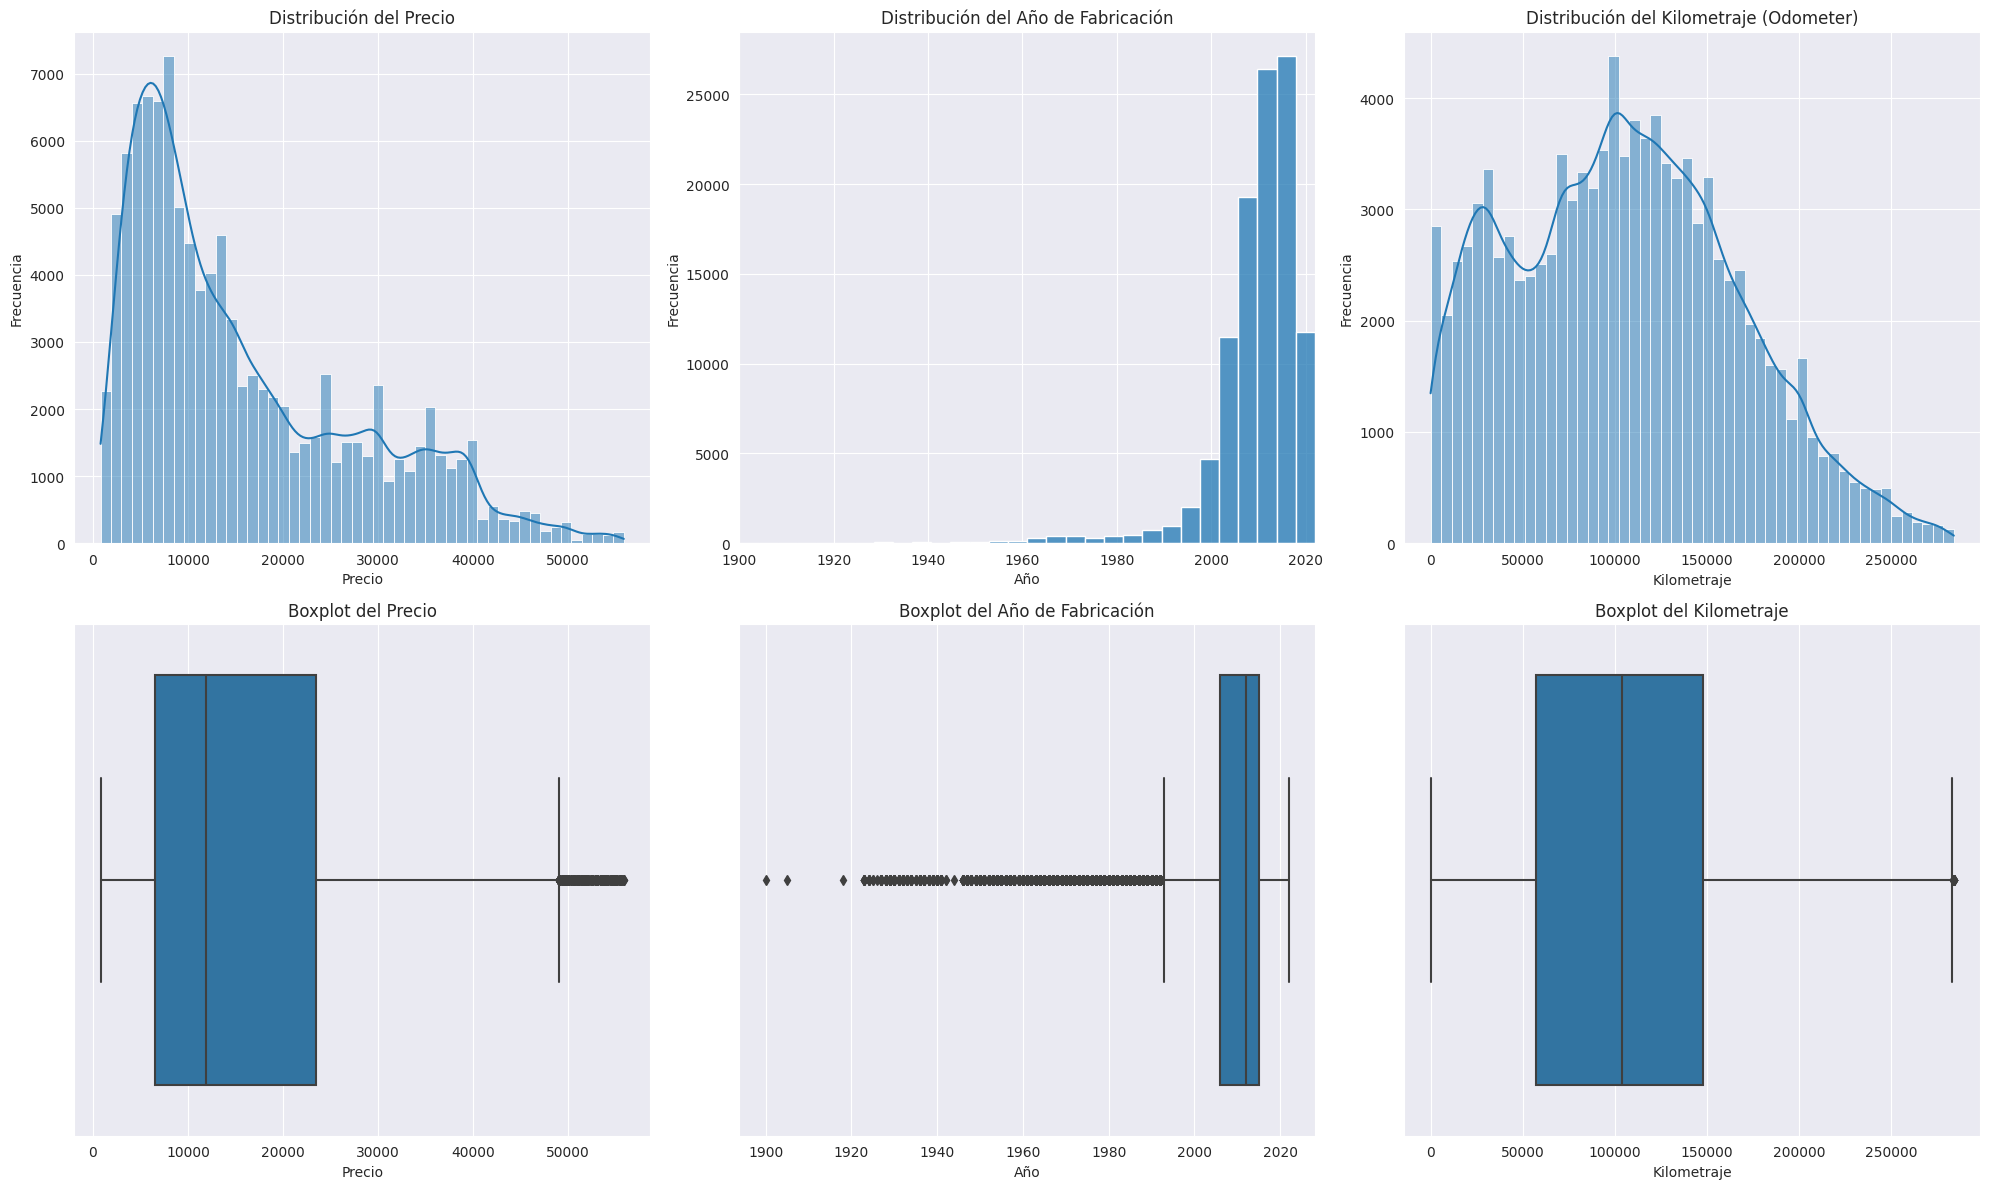

In [40]:
# Código de EDA inspirado en el PDF (páginas 14-21)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))  # Cambiado a 2 filas para incluir boxplots

# Histograma para 'price'
sns.histplot(df_cleaned['price'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribución del Precio')
axes[0, 0].set_xlabel('Precio')
axes[0, 0].set_ylabel('Frecuencia')

# Boxplot para 'price'
sns.boxplot(x=df_cleaned['price'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot del Precio')
axes[1, 0].set_xlabel('Precio')

# Histograma para 'year'
sns.histplot(df_cleaned['year'], bins=30, kde=False, ax=axes[0, 1])
axes[0, 1].set_title('Distribución del Año de Fabricación')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_xlim(df_cleaned['year'].min(), df_cleaned['year'].max())

# Boxplot para 'year'
sns.boxplot(x=df_cleaned['year'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot del Año de Fabricación')
axes[1, 1].set_xlabel('Año')

# Histograma para 'odometer'
sns.histplot(df_cleaned['odometer'], bins=50, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Distribución del Kilometraje (Odometer)')
axes[0, 2].set_xlabel('Kilometraje')
axes[0, 2].set_ylabel('Frecuencia')

# Boxplot para 'odometer'
sns.boxplot(x=df_cleaned['odometer'], ax=axes[1, 2])
axes[1, 2].set_title('Boxplot del Kilometraje')
axes[1, 2].set_xlabel('Kilometraje')

plt.tight_layout()
plt.show()

### **Ingeniería de características (HighDemand)**

In [41]:
# Tarea 1.5: Generar la variable binaria HighDemand
median_price = df_cleaned['price'].median()
df_cleaned['HighDemand'] = (df_cleaned['price'] > median_price).astype(int)

print(f"Variable 'HighDemand' creada. Mediana del precio: ${median_price:,.2f}")
print("\nDistribución de la nueva variable:")
print(df_cleaned['HighDemand'].value_counts(normalize=True))

Variable 'HighDemand' creada. Mediana del precio: $11,900.00

Distribución de la nueva variable:
HighDemand
0    0.500694
1    0.499306
Name: proportion, dtype: float64


## **Construcción de Pipelines**

In [42]:
# Importaciones de Scikit-learn para modelado
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Modelos a utilizar
from sklearn.linear_model import Ridge, Lasso, LogisticRegression

# Métricas de evaluación
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

print("Librerías de scikit-learn importadas.")

Librerías de scikit-learn importadas.


In [43]:
# Separar características (X) y objetivos (y)
X = df_cleaned.drop(columns=['price', 'HighDemand'])
y_reg = df_cleaned['price']  # Objetivo para regresión
y_clas = df_cleaned['HighDemand'] # Objetivo para clasificación

# Identificar columnas numéricas y categóricas
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Características numéricas ({len(numerical_features)}): {numerical_features}")
print(f"Características categóricas ({len(categorical_features)}): {categorical_features}")

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usaremos una división para ambas tareas para mantener la consistencia
X_train, X_test, y_reg_train, y_reg_test, y_clas_train, y_clas_test = train_test_split(
    X, y_reg, y_clas, test_size=0.2, random_state=3
)

print(f"\nDatos divididos: {len(X_train)} para entrenamiento, {len(X_test)} para prueba.")

Características numéricas (2): ['year', 'odometer']
Características categóricas (12): ['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']

Datos divididos: 85912 para entrenamiento, 21479 para prueba.


In [44]:
# Crear el pipeline de preprocesamiento
# Código inspirado en el concepto de Pipeline del PDF
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Mantiene columnas no especificadas (si las hubiera)
)

print("Preprocesador creado con StandardScaler para numéricas y OneHotEncoder para categóricas.")

Preprocesador creado con StandardScaler para numéricas y OneHotEncoder para categóricas.


In [45]:
# --- Modelo de Regresión Logística ---
# 1. Crear el Pipeline
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear'))
])

# 2. Definir el grid de hiperparámetros
param_grid_logreg = {
    'model__C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# 3. Configurar y ejecutar GridSearchCV
# Usamos AUC como métrica de scoring, es más robusta que accuracy
grid_search_logreg = GridSearchCV(logreg_pipeline, param_grid_logreg, cv=5, 
                                  scoring='roc_auc', n_jobs=-1)
print("Entrenando modelo de Regresión Logística con GridSearchCV...")
grid_search_logreg.fit(X_train, y_clas_train)

print(f"Mejor C para Regresión Logística: {grid_search_logreg.best_params_}")
best_logreg = grid_search_logreg.best_estimator_

Entrenando modelo de Regresión Logística con GridSearchCV...
Mejor C para Regresión Logística: {'model__C': 10.0}


--- Resultados de Evaluación (Clasificación) ---

Reporte de Clasificación:
                  precision    recall  f1-score   support

Baja Demanda (0)       0.89      0.90      0.90     10766
Alta Demanda (1)       0.90      0.89      0.89     10713

        accuracy                           0.89     21479
       macro avg       0.89      0.89      0.89     21479
    weighted avg       0.89      0.89      0.89     21479

Área Bajo la Curva ROC (AUC): 0.9590


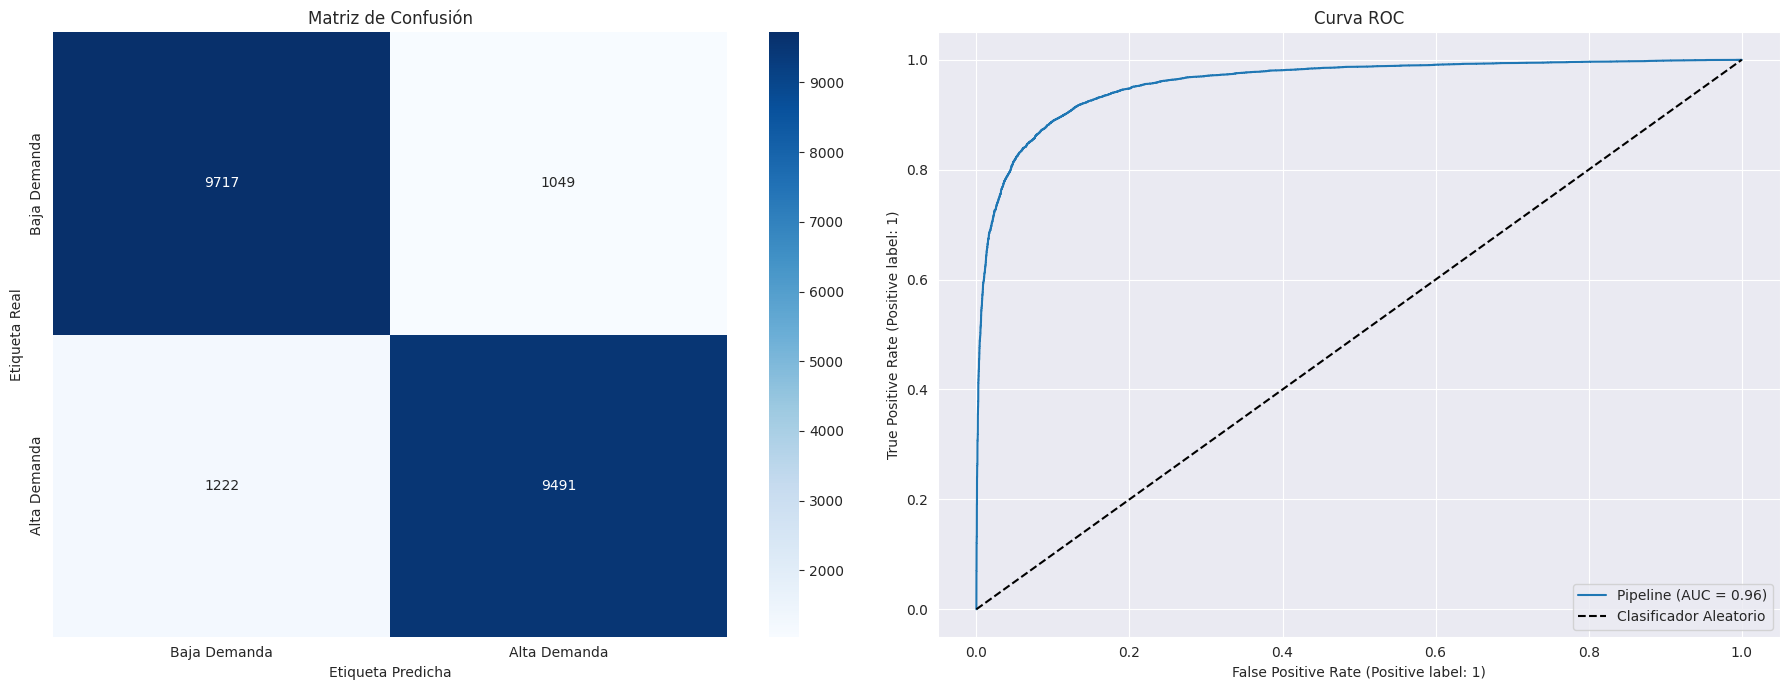

In [46]:
# Predicciones y probabilidades
y_pred_logreg = best_logreg.predict(X_test)
y_proba_logreg = best_logreg.predict_proba(X_test)[:, 1] # Probabilidad de la clase 1 (HighDemand)

# Reporte de Clasificación
print("--- Resultados de Evaluación (Clasificación) ---")
print("\nReporte de Clasificación:")
print(classification_report(y_clas_test, y_pred_logreg, target_names=['Baja Demanda (0)', 'Alta Demanda (1)']))

# AUC Score
auc = roc_auc_score(y_clas_test, y_proba_logreg)
print(f"Área Bajo la Curva ROC (AUC): {auc:.4f}")

# Gráficos: Matriz de Confusión y Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de Confusión
cm = confusion_matrix(y_clas_test, y_pred_logreg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Baja Demanda', 'Alta Demanda'],
            yticklabels=['Baja Demanda', 'Alta Demanda'])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Etiqueta Real')
axes[0].set_xlabel('Etiqueta Predicha')

# Curva ROC
RocCurveDisplay.from_estimator(best_logreg, X_test, y_clas_test, ax=axes[1])
axes[1].set_title('Curva ROC')
axes[1].plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
axes[1].legend()

plt.tight_layout()
plt.show()

## **GridSearchCV con validación cruzada**

## **Evaluación con métricas y gráficas**

## **Conclusiones**